# <b><center>CSCI 5415 Data Mining</center></b>
## <center><b>Group Name</b>: KAPPA</center>
## <center><b>Group Project Milestone</b>: Phase 5: Rule Miner Code </center>
## <b>Group Members:</b>
### <ul> 
### <li>Carmen Avitia(cavitia@nmsu.edu)</li>
### <li>Victoria Franco(vichol@nmsu.edu)</li>
### <li>Daniela Pedroza Rodriguez (dgpedroz@nmsu.edu)</li>
### <li>Ying Yang (yy0816@nmsu.edu)</li></ul>
## <b>Data Source</b>: 
### <ul>
### <li> Global Super Store Dataset: https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset/data</li>
### <li>E-commerce Consumer Behavior Dataset: https://www.kaggle.com/datasets/hunter0007/ecommerce-dataset-for-predictive-marketing-2023/data</li></ul>
#### <b>Submission Date</b>: 11/08/2025

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import warnings
warnings.filterwarnings("ignore",category=Warning)
pd.set_option("display.width",500)
pd.set_option("display.max_rows",1000)
pd.set_option("display.max_columns",None)

In [2]:
import kagglehub 
path2 = kagglehub.dataset_download("hunter0007/ecommerce-dataset-for-predictive-marketing-2023")
path1= kagglehub.dataset_download("apoorvaappz/global-super-store-dataset")

In [3]:
# Load Datasets
df = pd.read_csv(os.path.join(path1, "Global_Superstore2.csv"), encoding="latin1")
df2 = pd.read_csv(os.path.join(path2, "ECommerce_consumer behaviour.csv"), encoding="latin1")

## <hr />
### <b>Global Supermarket Dataset</b>
## <hr />

In [4]:
print(df.shape)
print(df.columns)

# Parse dates
date_cols = []
for col in ["Order Date", "Ship Date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])
        date_cols.append(col)

print("Parsed date columns:", date_cols)

# Dropping rows with missing key identifiers
key_cols = [c for c in ["Order ID", "Customer ID", "Order Date", "Sales", "Profit"] if c in df.columns]
df = df.dropna(subset=key_cols)

# to remove negative or zero sales/profit if they exist (business decision)
df = df[(df["Sales"] > 0) & (df["Profit"] >= 0)]

df.info()


(51290, 24)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority'], dtype='object')
Parsed date columns: ['Order Date', 'Ship Date']
<class 'pandas.core.frame.DataFrame'>
Index: 38746 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          38746 non-null  int64         
 1   Order ID        38746 non-null  object        
 2   Order Date      38746 non-null  datetime64[ns]
 3   Ship Date       38746 non-null  datetime64[ns]
 4   Ship Mode       38746 non-null  object        
 5   Customer ID     38746 non-null  object        
 6   Customer Name   38746 non-null  object        
 7   Segment         38746 non-null  ob

#### High Value Customer Classification Predictions

In [5]:
#setting a reference date to be the last order date in the dataset
last_date = df["Order Date"].max()
print("Last order date in dataset:", last_date)

Last order date in dataset: 2014-12-31 00:00:00


In [6]:
# aggregating customer level
cust_agg = df.groupby("Customer ID").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum",
    "Order ID": "nunique",
    "Order Date": ["min", "max"]
})

cust_agg.columns = [
    "Total_Sales",
    "Total_Profit",
    "Total_Quantity",
    "Order_Count",
    "First_Order_Date",
    "Last_Order_Date"
]

# recency and active duration (in days)
cust_agg["Recency"] = (last_date - cust_agg["Last_Order_Date"]).dt.days
cust_agg["Active_Duration"] = (cust_agg["Last_Order_Date"] - cust_agg["First_Order_Date"]).dt.days

# avg order value and average profit per order
cust_agg["Avg_Order_Value"] = cust_agg["Total_Sales"] / cust_agg["Order_Count"]
cust_agg["Avg_Profit_per_Order"] = cust_agg["Total_Profit"] / cust_agg["Order_Count"]

cust_agg.head()


,Total_Sales,Total_Profit,Total_Quantity,Order_Count,First_Order_Date,Last_Order_Date,Recency,Active_Duration,Avg_Order_Value,Avg_Profit_per_Order
Customer ID,,,,,,,,,,
AA-10315,9003.54450,1454.03840,106,16,2011-03-31,2014-12-23,8,1363,562.721531,90.877400
AA-10375,4787.28400,1525.23640,105,18,2011-04-21,2014-12-25,6,1344,265.960222,84.735356
AA-10480,11848.73428,1833.35968,126,16,2011-05-04,2014-05-16,229,1108,740.545893,114.584980
AA-10645,13454.85314,3390.17694,207,32,2011-01-26,2014-11-24,37,1398,420.464161,105.943029
AA-315,2072.34000,762.27000,17,4,2013-08-08,2014-07-31,153,357,518.085000,190.567500


##### Categotical Features (segment, Region, Market)

In [7]:
# taking the most frequent value per customer 

def mode_or_nan(x):
    return x.mode().iloc[0] if not x.mode().empty else np.nan

cat_features = {}

for col in ["Segment", "Region", "Market"]:
    if col in df.columns:
        cat = df.groupby("Customer ID")[col].apply(mode_or_nan)
        cat_features[col] = cat

cat_features = pd.DataFrame(cat_features)

# merging with customer aggregates
cust_df = cust_agg.join(cat_features, how="left")

cust_df.head()

,Total_Sales,Total_Profit,Total_Quantity,Order_Count,First_Order_Date,Last_Order_Date,Recency,Active_Duration,Avg_Order_Value,Avg_Profit_per_Order,Segment,Region,Market
Customer ID,,,,,,,,,,,,,
AA-10315,9003.54450,1454.03840,106,16,2011-03-31,2014-12-23,8,1363,562.721531,90.877400,Consumer,North,EU
AA-10375,4787.28400,1525.23640,105,18,2011-04-21,2014-12-25,6,1344,265.960222,84.735356,Consumer,South,US
AA-10480,11848.73428,1833.35968,126,16,2011-05-04,2014-05-16,229,1108,740.545893,114.584980,Consumer,Central,US
AA-10645,13454.85314,3390.17694,207,32,2011-01-26,2014-11-24,37,1398,420.464161,105.943029,Consumer,Central,APAC
AA-315,2072.34000,762.27000,17,4,2013-08-08,2014-07-31,153,357,518.085000,190.567500,Consumer,EMEA,EMEA


#### High value label for customers (a profit of >0.75)

In [8]:
# Label: High_Value = 1 if Total_Profit > 0.75, else 0
cust_df["High_Value"] = (cust_df["Total_Profit"] > 0.75).astype(int)

cust_df["High_Value"].value_counts(normalize=True)

High_Value
1    0.998735
0    0.001265
Name: proportion, dtype: float64

#### Pipeline 

In [9]:
# deopping columns we don't want as features
cust_features = cust_df.drop(columns=[
    "First_Order_Date", "Last_Order_Date", "High_Value"
])

target = cust_df["High_Value"]

# identifying numeric and categorical columns
numeric_cols = cust_features.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [
    c for c in cust_features.columns
    if c not in numeric_cols
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# preprocessing: scale numeric, one-hot encode categorical
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# chosen model based off last part due to perfromance: Random Forest 
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

pipe_cust_value = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", clf)
])

X_train, X_test, y_train, y_test = train_test_split(
    cust_features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

pipe_cust_value.fit(X_train, y_train)

print("Train accuracy:", pipe_cust_value.score(X_train, y_train))
print("Test accuracy:", pipe_cust_value.score(X_test, y_test))


Numeric columns: ['Total_Sales', 'Total_Profit', 'Total_Quantity', 'Order_Count', 'Recency', 'Active_Duration', 'Avg_Order_Value', 'Avg_Profit_per_Order']
Categorical columns: ['Segment', 'Region', 'Market']
Train accuracy: 1.0
Test accuracy: 1.0


#### Customer-Product Reorder Prediction

In [10]:
# treat a "reorder" as the same customer buying the same product in >1 different orders.

cust_prod_freq = (
    df.groupby(["Customer ID", "Product ID"])["Order ID"]
      .nunique()
      .reset_index(name="Order_Frequency")
)

cust_prod_freq["Reordered"] = (cust_prod_freq["Order_Frequency"] > 1).astype(int)

cust_prod_freq["Reordered"].value_counts(normalize=True)
cust_prod_freq.head()

,Customer ID,Product ID,Order_Frequency,Reordered
0,AA-10315,FUR-BO-10000961,1,0
1,AA-10315,FUR-BO-10001553,1,0
2,AA-10315,FUR-BO-10004430,1,0
3,AA-10315,FUR-FU-10002456,1,0
4,AA-10315,OFF-AP-10000576,1,0


In [11]:
# Aggregate product-level information
prod_agg = df.groupby("Product ID").agg({
    "Sales": ["mean", "sum"],
    "Profit": ["mean", "sum"],
    "Discount": "mean",
    "Quantity": "mean",
    "Category": "first",
    "Sub-Category": "first"
})

prod_agg.columns = [
    "Prod_Avg_Sales",
    "Prod_Total_Sales",
    "Prod_Avg_Profit",
    "Prod_Total_Profit",
    "Prod_Avg_Discount",
    "Prod_Avg_Quantity",
    "Category",
    "Sub_Category"
]

prod_agg.head()

,Prod_Avg_Sales,Prod_Total_Sales,Prod_Avg_Profit,Prod_Total_Profit,Prod_Avg_Discount,Prod_Avg_Quantity,Category,Sub_Category
Product ID,,,,,,,,
FUR-ADV-10000002,79.560,159.12,30.195,60.39,0.0,1.500000,Furniture,Furnishings
FUR-ADV-10000108,116.690,350.07,1.120,3.36,0.0,2.333333,Furniture,Furnishings
FUR-ADV-10000183,116.556,582.78,1.122,5.61,0.0,2.200000,Furniture,Furnishings
FUR-ADV-10000188,33.320,99.96,10.320,30.96,0.0,1.333333,Furniture,Furnishings
FUR-ADV-10000190,222.360,222.36,104.460,104.46,0.0,2.000000,Furniture,Furnishings


In [12]:
# merging customer–product frequency with product-level features
reorder_df = cust_prod_freq.merge(
    prod_agg,
    on="Product ID",
    how="left"
)

#  adding customer-level features
reorder_df = reorder_df.merge(
    cust_df[["Total_Sales", "Total_Profit", "Recency", "Active_Duration"]],
    left_on="Customer ID",
    right_index=True,
    how="left"
)

reorder_df.head()

,Customer ID,Product ID,Order_Frequency,Reordered,Prod_Avg_Sales,Prod_Total_Sales,Prod_Avg_Profit,Prod_Total_Profit,Prod_Avg_Discount,Prod_Avg_Quantity,Category,Sub_Category,Total_Sales,Total_Profit,Recency,Active_Duration
0,AA-10315,FUR-BO-10000961,1,0,471.346500,1885.386,151.666500,606.6660,0.050000,4.000000,Furniture,Bookcases,9003.5445,1454.0384,8,1363
1,AA-10315,FUR-BO-10001553,1,0,1679.730000,5039.190,16.770000,50.3100,0.000000,4.333333,Furniture,Bookcases,9003.5445,1454.0384,8,1363
2,AA-10315,FUR-BO-10004430,1,0,554.872500,2219.490,49.920000,199.6800,0.000000,3.250000,Furniture,Bookcases,9003.5445,1454.0384,8,1363
3,AA-10315,FUR-FU-10002456,1,0,23.296000,139.776,8.080800,48.4848,0.100000,3.666667,Furniture,Furnishings,9003.5445,1454.0384,8,1363
4,AA-10315,OFF-AP-10000576,1,0,287.264571,2010.852,53.783914,376.4874,0.057143,4.142857,Office Supplies,Appliances,9003.5445,1454.0384,8,1363


In [13]:
reorder_features = reorder_df.drop(columns=["Reordered"])
reorder_target = reorder_df["Reordered"]

# identifying numeric and categorical columns
reorder_num_cols = reorder_features.select_dtypes(include=[np.number]).columns.tolist()
reorder_cat_cols = [
    c for c in reorder_features.columns
    if c not in reorder_num_cols
]

print("Numeric columns (reorder):", reorder_num_cols)
print("Categorical columns (reorder):", reorder_cat_cols)

reorder_numeric_transformer = StandardScaler()
reorder_categorical_transformer = OneHotEncoder(handle_unknown="ignore")

reorder_preprocess = ColumnTransformer(
    transformers=[
        ("num", reorder_numeric_transformer, reorder_num_cols),
        ("cat", reorder_categorical_transformer, reorder_cat_cols)
    ]
)

reorder_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

pipe_reorder = Pipeline(steps=[
    ("preprocess", reorder_preprocess),
    ("model", reorder_clf)
])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    reorder_features,
    reorder_target,
    test_size=0.2,
    random_state=42,
    stratify=reorder_target
)

pipe_reorder.fit(Xr_train, yr_train)

print("Train accuracy (reorder):", pipe_reorder.score(Xr_train, yr_train))
print("Test accuracy (reorder):", pipe_reorder.score(Xr_test, yr_test))


Numeric columns (reorder): ['Order_Frequency', 'Prod_Avg_Sales', 'Prod_Total_Sales', 'Prod_Avg_Profit', 'Prod_Total_Profit', 'Prod_Avg_Discount', 'Prod_Avg_Quantity', 'Total_Sales', 'Total_Profit', 'Recency', 'Active_Duration']
Categorical columns (reorder): ['Customer ID', 'Product ID', 'Category', 'Sub_Category']
Train accuracy (reorder): 1.0
Test accuracy (reorder): 0.9968903861103913


### Association Rules: Apriori and FP-Growth

In [14]:
# Count product frequency across all orders
prod_counts = df["Product Name"].value_counts()

# Keep top N products (tune N as needed)
TOP_N = 200
top_products = prod_counts.head(TOP_N).index

df_top = df[df["Product Name"].isin(top_products)].copy()

# Build basket: Order ID × Product Name, 0/1 indicating presence
basket = (
    df_top.groupby(["Order ID", "Product Name"])["Quantity"]
          .sum()
          .unstack()
          .fillna(0)
)

basket = (basket > 0).astype(int)

basket.head()


Product Name,"Acco 3-Hole Punch, Durable","Acco 3-Hole Punch, Economy","Acco Binder Covers, Clear","Acco Binder Covers, Economy","Acco Binder Covers, Recycled","Acco Binder, Clear","Acco Binder, Durable","Acco Binder, Economy","Acco Binding Machine, Clear","Acco Binding Machine, Durable","Acco Binding Machine, Recycled","Acco Hole Reinforcements, Clear","Acco Hole Reinforcements, Recycled","Acco Index Tab, Clear","Acco Index Tab, Durable","Acco Index Tab, Economy","Accos Paper Clips, Assorted Sizes","Advantus Paper Clips, Assorted Sizes","Apple Smart Phone, Full Size","Avery 3-Hole Punch, Clear","Avery 3-Hole Punch, Durable","Avery 3-Hole Punch, Recycled","Avery Binder Covers, Durable","Avery Binder Covers, Economy","Avery Binder Covers, Recycled","Avery Binder, Clear","Avery Binder, Economy","Avery Binding Machine, Clear","Avery Binding Machine, Durable","Avery Binding Machine, Economy","Avery Hole Reinforcements, Durable","Avery Hole Reinforcements, Economy","Avery Hole Reinforcements, Recycled","Avery Index Tab, Clear","Avery Index Tab, Durable","BIC Canvas, Fluorescent","BIC Highlighters, Blue","BIC Highlighters, Water Color","BIC Markers, Easy-Erase","BIC Markers, Water Color","BIC Pencil Sharpener, Blue","BIC Pens, Easy-Erase","BIC Sketch Pad, Water Color","Belkin Numeric Keypad, Bluetooth","Binney & Smith Highlighters, Water Color","Binney & Smith Markers, Blue","Binney & Smith Markers, Easy-Erase","Binney & Smith Markers, Fluorescent","Binney & Smith Pencil Sharpener, Easy-Erase","Binney & Smith Pencil Sharpener, Water Color","Binney & Smith Pens, Blue","Binney & Smith Pens, Water Color","Binney & Smith Sketch Pad, Blue","Binney & Smith Sketch Pad, Fluorescent","Boston Canvas, Fluorescent","Boston Highlighters, Easy-Erase","Boston Markers, Blue","Boston Markers, Fluorescent","Boston Pencil Sharpener, Easy-Erase","Boston Pencil Sharpener, Water Color","Boston Pens, Fluorescent","Boston Sketch Pad, Blue","Boston Sketch Pad, Fluorescent","Brother Copy Machine, Color","Bush Stackable Bookrack, Pine","Cardinal 3-Hole Punch, Clear","Cardinal 3-Hole Punch, Durable","Cardinal 3-Hole Punch, Economy","Cardinal Binder Covers, Clear","Cardinal Binder Covers, Durable","Cardinal Binder Covers, Economy","Cardinal Binder Covers, Recycled","Cardinal Binder, Durable","Cardinal Binder, Economy","Cardinal Binder, Recycled","Cardinal Binding Machine, Clear","Cardinal Binding Machine, Durable","Cardinal Binding Machine, Economy","Cardinal Hole Reinforcements, Clear","Cardinal Hole Reinforcements, Recycled","Cardinal Index Tab, Clear","Cardinal Index Tab, Durable","Cardinal Index Tab, Economy","Cisco Smart Phone, Full Size","Eldon Box, Industrial","Eldon File Cart, Single Width","Eldon Shelving, Blue","Enermax Note Cards, Premium","Fellowes Box, Wire Frame","Fellowes File Cart, Wire Frame","Fellowes Folders, Blue","Fellowes Folders, Single Width","Fellowes Lockers, Industrial","Fellowes Lockers, Single Width","Fellowes Lockers, Wire Frame","Fellowes Shelving, Single Width","Fellowes Shelving, Wire Frame","Fellowes Trays, Industrial","Fellowes Trays, Wire Frame","Fiskars Letter Opener, Easy Grip","Green Bar Note Cards, Premium","HP Copy Machine, Color","Harbour Creations Executive Leather Armchair, Adjustable","Harbour Creations Removable Labels, Adjustable","Hewlett Copy Machine, Color","Hon Executive Leather Armchair, Adjustable","Hon Swivel Stool, Black","Ibico 3-Hole Punch, Durable","Ibico 3-Hole Punch, Recycled","Ibico Binder Covers, Clear","Ibico Binder Covers, Durable","Ibico Binder Covers, Economy","Ibico Binder Covers, Recycled","Ibico Binder, Clear","Ibico Binder, Durable","Ibico Binder, Recycled","Ibico Binding Machine, Durable","Ibico Binding Machine, Recycled","Ibico Hole Reinforcements, Economy","Ibico Hole Reinforcements, Recycled","Ibico Index Tab, Clear","Ibico Index Tab, Economy","Jiffy Business Envelopes, Recycled","Kleencut Letter Opener, Easy Grip","Memorex Numeric Keypad, Bluetooth","Nokia Smart Phone, Full Size","Novime

In [15]:
# confirming the most frequently purchased products
basket.sum().sort_values(ascending=False).head(10)


Product Name
Staples                                  208
Cardinal Index Tab, Clear                 81
Eldon File Cart, Single Width             73
Stanley Pencil Sharpener, Water Color     64
Acco Index Tab, Clear                     63
Sanford Pencil Sharpener, Water Color     62
Avery Index Tab, Clear                    60
Ibico Index Tab, Clear                    58
Rogers File Cart, Single Width            55
Tenex File Cart, Single Width             51
dtype: int64

In [16]:
# restricting to high value customers 

# Add Customer ID to each order
order_customer = df.groupby("Order ID")["Customer ID"].first()

# Align to basket index
basket_with_cust = basket.copy()
basket_with_cust["Customer ID"] = order_customer.loc[basket.index].values

# High-value customers
hv_customers = cust_df[cust_df["High_Value"] == 1].index

# Filter basket to orders from high-value customers only
basket_hv = basket_with_cust[basket_with_cust["Customer ID"].isin(hv_customers)].drop(columns=["Customer ID"])

print("Original basket shape:", basket.shape)
print("High-value basket shape:", basket_hv.shape)


Original basket shape: (5827, 200)
High-value basket shape: (5826, 200)


In [17]:
print(basket.shape)
print("Non-empty rows:", (basket.sum(axis=1) > 0).sum())
print("Binary check:", basket.dtypes.unique())
basket.iloc[:, :5].head()
# How many products per order?
basket.sum(axis=1).value_counts().head(10)


(5827, 200)
Non-empty rows: 5827
Binary check: [dtype('int64')]


1    4838
2     802
3     141
4      37
5       8
6       1
Name: count, dtype: int64

In [18]:
basket_multi = basket[basket.sum(axis=1) > 1]
print(f"Orders before filtering: {basket.shape[0]}")
print(f"Orders with >1 product: {basket_multi.shape[0]}")

min_orders = 20  # product appears in at least 20 orders
freq_products = basket_multi.columns[basket_multi.sum() >= min_orders]
basket_reduced = basket_multi[freq_products]
print(f"Reduced basket shape: {basket_reduced.shape}")


Orders before filtering: 5827
Orders with >1 product: 989
Reduced basket shape: (989, 6)


##### Apriori

In [19]:
support_values = [0.001, 0.002]
freq_items_ap_dict = {}

for s in support_values:
    freq = apriori(
        basket_reduced,
        min_support=s,
        use_colnames=True,
        max_len=3
    )
    freq_items_ap_dict[s] = freq
    print(f"min_support={s}: {len(freq)} frequent itemsets (Apriori)")
    
support_final = 0.001 
freq_items_ap = freq_items_ap_dict[support_final]
print(f"Using min_support={support_final} for rule generation (Apriori)")

min_support=0.001: 13 frequent itemsets (Apriori)
min_support=0.002: 7 frequent itemsets (Apriori)
Using min_support=0.001 for rule generation (Apriori)


##### FP-Growth

In [20]:
freq_items_fp = fpgrowth(
    basket_reduced,
    min_support=support_final,
    use_colnames=True,
    max_len=3
)

print(f"FP-Growth frequent itemsets (min_support={support_final}): {len(freq_items_fp)}")

FP-Growth frequent itemsets (min_support=0.001): 13


In [23]:
freq_items_ap["k"] = freq_items_ap["itemsets"].apply(len)
print("Apriori itemset sizes:\n", freq_items_ap["k"].value_counts())
freq_items_fp["k"] = freq_items_fp["itemsets"].apply(len)
print("\nFP-Growth itemset sizes:\n", freq_items_fp["k"].value_counts())


Apriori itemset sizes:
 k
2    7
1    6
Name: count, dtype: int64

FP-Growth itemset sizes:
 k
2    7
1    6
Name: count, dtype: int64


In [25]:
# Generate association rules using confidence and lift
rules_ap = association_rules(freq_items_ap, metric="confidence", min_threshold=0.01)
rules_fp = association_rules(freq_items_fp, metric="confidence", min_threshold=0.01)

print("Rules (Apriori):", len(rules_ap))
print("Rules (FP-Growth):", len(rules_fp))

# Label methods
if not rules_ap.empty:
    rules_ap["Method"] = "Apriori"
if not rules_fp.empty:
    rules_fp["Method"] = "FP-Growth"

# Combine
all_rules = pd.concat([rules_ap, rules_fp], ignore_index=True)
print("Total combined rules:", len(all_rules))

# Preview
all_rules.sort_values("lift", ascending=False).head(10)


Rules (Apriori): 14
Rules (FP-Growth): 14
Total combined rules: 28


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,Method
18,"(Rogers File Cart, Single Width)","(Stanley Pencil Sharpener, Water Color)",0.026289,0.030334,0.002022,0.076923,2.535897,1.0,0.001225,1.050472,0.622015,0.037037,0.048047,0.071795,FP-Growth
12,"(Rogers File Cart, Single Width)","(Stanley Pencil Sharpener, Water Color)",0.026289,0.030334,0.002022,0.076923,2.535897,1.0,0.001225,1.050472,0.622015,0.037037,0.048047,0.071795,Apriori
13,"(Stanley Pencil Sharpener, Water Color)","(Rogers File Cart, Single Width)",0.030334,0.026289,0.002022,0.066667,2.535897,1.0,0.001225,1.043262,0.624609,0.037037,0.041468,0.071795,Apriori
19,"(Stanley Pencil Sharpener, Water Color)","(Rogers File Cart, Single Width)",0.030334,0.026289,0.002022,0.066667,2.535897,1.0,0.001225,1.043262,0.624609,0.037037,0.041468,0.071795,FP-Growth
5,"(Ibico Index Tab, Clear)","(Avery Index Tab, Clear)",0.021234,0.023256,0.001011,0.047619,2.047619,1.0,0.000517,1.025581,0.522727,0.023256,0.024943,0.045549,Apriori
4,"(Avery Index Tab, Clear)","(Ibico Index Tab, Clear)",0.023256,0.021234,0.001011,0.043478,2.047619,1.0,0.000517,1.023256,0.523810,0.023256,0.022727,0.045549,Apriori
23,"(Ibico Index Tab, Clear)","(Avery Index Tab, Clear)",0.021234,0.023256,0.001011,0.047619,2.047619,1.0,0.000517,1.025581,0.522727,0.023256,0.024943,0.045549,FP-Growth
22,"(Avery Index Tab, Clear)","(Ibico Index Tab, Clear)",0.023256,0.021234,0.001011,0.043478,2.047619,1.0,0.000517,1.023256,0.523810,0.023256,0.022727,0.045549,FP-Growth
26,"(Eldon File Cart, Single Width)","(Avery Index Tab, Clear)",0.023256,0.023256,0.001011,0.043478,1.869565,1.0,0.000470,1.021142,0.476190,0.022222,0.020704,0.043478,FP-Growth
27,"(Avery Index Tab, Clear)","(Eldon File Cart, Single Width)",0.023256,0.023256,0.001011,0.043478,1.869565,1.0,0.000470,1.021142,0.476190,0.022222,0.020704,0.043478,FP-Growth


#### Pruning strategy

In [28]:
# keep only rules with a single-item consequent
rules_pruned = all_rules[all_rules["consequents"].apply(lambda x: len(x) == 1)].copy()

# sort by lift (so higher-quality rules are considered first)
rules_pruned = rules_pruned.sort_values("lift", ascending=False).reset_index(drop=True)

# redundancy pruning: remove rules subsumed by higher-lift rules
non_redundant = []
for _, row in rules_pruned.iterrows():
    ant = row["antecedents"]
    cons = row["consequents"]
    is_subsumed = False
    
    for kept in non_redundant:
        if ant.issubset(kept["antecedents"]) and cons.issubset(kept["consequents"]):
            is_subsumed = True
            break
    
    if not is_subsumed:
        non_redundant.append(row)

rules_pruned = pd.DataFrame(non_redundant)

print("Rules before pruning:", len(all_rules))
print("After redundancy pruning:", len(rules_pruned))

# apply numeric thresholds to cut very weak rules
rules_pruned = rules_pruned[
    (rules_pruned["support"]   >= 0.001) &  
    (rules_pruned["confidence"] >= 0.01) &    
    (rules_pruned["lift"]       >= 1.1)
].reset_index(drop=True)

print("After applying support/confidence/lift thresholds:", len(rules_pruned))
rules_pruned.head(10)


Rules before pruning: 28
After redundancy pruning: 14
After applying support/confidence/lift thresholds: 14


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,Method
0,"(Rogers File Cart, Single Width)","(Stanley Pencil Sharpener, Water Color)",0.026289,0.030334,0.002022,0.076923,2.535897,1.0,0.001225,1.050472,0.622015,0.037037,0.048047,0.071795,FP-Growth
1,"(Stanley Pencil Sharpener, Water Color)","(Rogers File Cart, Single Width)",0.030334,0.026289,0.002022,0.066667,2.535897,1.0,0.001225,1.043262,0.624609,0.037037,0.041468,0.071795,Apriori
2,"(Ibico Index Tab, Clear)","(Avery Index Tab, Clear)",0.021234,0.023256,0.001011,0.047619,2.047619,1.0,0.000517,1.025581,0.522727,0.023256,0.024943,0.045549,Apriori
3,"(Avery Index Tab, Clear)","(Ibico Index Tab, Clear)",0.023256,0.021234,0.001011,0.043478,2.047619,1.0,0.000517,1.023256,0.523810,0.023256,0.022727,0.045549,Apriori
4,"(Eldon File Cart, Single Width)","(Avery Index Tab, Clear)",0.023256,0.023256,0.001011,0.043478,1.869565,1.0,0.000470,1.021142,0.476190,0.022222,0.020704,0.043478,FP-Growth
5,"(Avery Index Tab, Clear)","(Eldon File Cart, Single Width)",0.023256,0.023256,0.001011,0.043478,1.869565,1.0,0.000470,1.021142,0.476190,0.022222,0.020704,0.043478,FP-Growth
6,"(Eldon File Cart, Single Width)","(Rogers File Cart, Single Width)",0.023256,0.026289,0.001011,0.043478,1.653846,1.0,0.000400,1.017970,0.404762,0.020833,0.017653,0.040970,FP-Growth
7,"(Rogers File Cart, Single Width)","(Eldon File Cart, Single Width)",0.026289,0.023256,0.001011,0.038462,1.653846,1.0,0.000400,1.015814,0.406023,0.020833,0.015568,0.040970,FP-Growth
8,"(Ibico Index Tab, Clear)","(Stanley Pencil Sharpener, Water Color)",0.021234,0.030334,0.001011,0.047619,1.569841,1.0,0.000367,1.018150,0.370868,0.020000,0.017826,0.040476,FP-Growth
9,"(Stanley Pencil Sharpener, Water Color)","(Ibico Index Tab, Clear)",0.030334,0.021234,0.001011,0.033333,1.569841,1.0,0.000367,1.012517,0.374348,0.020000,0.012362,0.040476,Apriori


In [29]:
n_transactions = basket_reduced.shape[0]
final_rules = rules_pruned.copy()

# add counts
final_rules["rule_count"] = (final_rules["support"] * n_transactions).round().astype(int)
if "antecedent_support" in final_rules.columns:
    final_rules["antecedent_count"] = (final_rules["antecedent_support"] * n_transactions).round().astype(int)
if "consequent_support" in final_rules.columns:
    final_rules["consequent_count"] = (final_rules["consequent_support"] * n_transactions).round().astype(int)

# order columns for export
export_cols = [
    "antecedents", "consequents", "support", "confidence", "lift",
    "leverage", "conviction",
    "antecedent_support", "consequent_support",
    "antecedent_count", "consequent_count", "rule_count", "Method"
]

export_cols = [c for c in export_cols if c in final_rules.columns]

group_name = "KAPPA" 
final_rules[export_cols].to_csv(f"rules_{group_name}_global.csv", index=False)



#### Visualizations

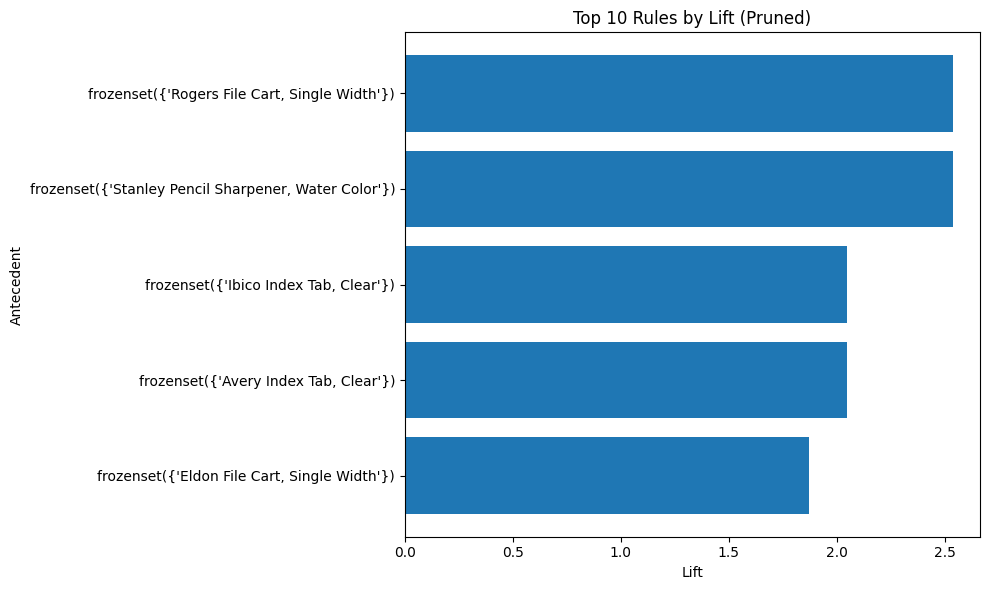

In [30]:
# top k rules by lift

top_k = 10
top_rules = rules_pruned.sort_values("lift", ascending=False).head(top_k)

plt.figure(figsize=(10, 6))
plt.barh(top_rules["antecedents"].astype(str), top_rules["lift"])
plt.gca().invert_yaxis()
plt.xlabel("Lift")
plt.ylabel("Antecedent")
plt.title(f"Top {top_k} Rules by Lift (Pruned)")
plt.tight_layout()
plt.show()



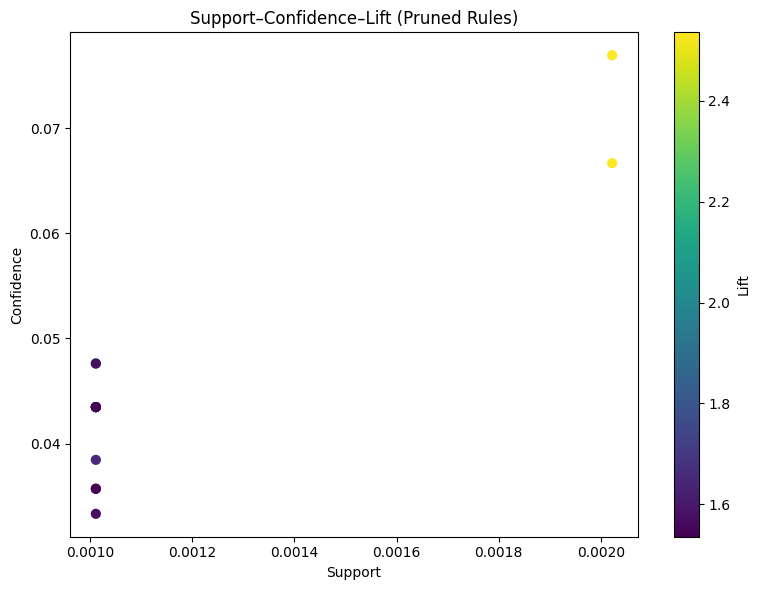

In [31]:
# support confidence lift scatter plot 

plt.figure(figsize=(8, 6))
plt.scatter(
    rules_pruned["support"],
    rules_pruned["confidence"],
    s=40,
    c=rules_pruned["lift"]
)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support–Confidence–Lift (Pruned Rules)")
plt.colorbar(label="Lift")
plt.tight_layout()
plt.show()

## <hr />
### <b>E-Commerce Dataset</b>
## <hr />

In [32]:
print(df2.shape)
print(df2.dtypes)
print(df2.head())

(2019501, 12)
order_id                    int64
user_id                     int64
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
department_id               int64
department                 object
product_name               object
dtype: object
   order_id  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order  product_id  add_to_cart_order  reordered  department_id  department        product_name
0   2425083    49125             1          2                 18                     NaN          17                  1          0             13      pantry  baking ingredients
1   2425083    49125             1          2                 18                     NaN          91                  2          0             16  dairy eggs     soy lactosefree
2   2425083    49125          

### Preprocessing

In [33]:
df2_clean = df2.copy()

# dropping rows missing key identifiers
df2_clean = df2_clean.dropna(subset=['order_id', 'user_id', 'product_id', 'product_name'])

# standardizing  string columns
df2_clean['product_name'] = df2_clean['product_name'].str.strip().str.lower()
df2_clean['department']   = df2_clean['department'].astype(str).str.strip().str.lower()

# ensuring numeric dtypes
numeric_cols = [
    'order_id', 'user_id', 'order_number',
    'order_dow', 'order_hour_of_day',
    'days_since_prior_order', 'product_id',
    'add_to_cart_order', 'reordered', 'department_id'
]

for col in numeric_cols:
    if col in df2_clean.columns:
        df2_clean[col] = pd.to_numeric(df2_clean[col], errors='coerce')

# dropping rows where these core numeric identifiers got coerced to NaN
df2_clean = df2_clean.dropna(subset=['order_id', 'user_id', 'product_id'])

# making reordered boolean/int (0/1)
df2_clean['reordered'] = df2_clean['reordered'].fillna(0).astype(int)

df2_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019501 entries, 0 to 2019500
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   order_number            int64  
 3   order_dow               int64  
 4   order_hour_of_day       int64  
 5   days_since_prior_order  float64
 6   product_id              int64  
 7   add_to_cart_order       int64  
 8   reordered               int64  
 9   department_id           int64  
 10  department              object 
 11  product_name            object 
dtypes: float64(1), int64(9), object(2)
memory usage: 184.9+ MB


#### Orders useful for Reordering Analysis

In [34]:
df2_hist = df2_clean[df2_clean['order_number'] > 1].copy()

print("Total rows in df2_clean:", len(df2_clean))
print("Rows with order_number > 1 (df2_hist):", len(df2_hist))

print(df2_hist['reordered'].value_counts(normalize=True))

Total rows in df2_clean: 2019501
Rows with order_number > 1 (df2_hist): 1895159
reordered
1    0.628436
0    0.371564
Name: proportion, dtype: float64


### Item frequency and pruning

In [35]:
MIN_ITEM_FREQ = 500   # min number of orders containing the product
base_df = df2_hist
product_counts = base_df['product_name'].value_counts()

# filtering to popular products
popular_products = product_counts[product_counts >= MIN_ITEM_FREQ].index
print(f"Number of popular products (>= {MIN_ITEM_FREQ} orders):", len(popular_products))

base_df_pop = base_df[base_df['product_name'].isin(popular_products)].copy()
print("Rows after filtering to popular products:", len(base_df_pop))


Number of popular products (>= 500 orders): 130
Rows after filtering to popular products: 1893583


#### Building order-level basket 

In [36]:
basket_orders = (
    base_df_pop
    .groupby(['order_id', 'product_name'])['product_name']
    .count()
    .unstack(fill_value=0)
)

# converting counts to 0/1 for presence/absence
basket_orders = (basket_orders > 0).astype(int)

print(basket_orders.shape)
basket_orders.head()

(187742, 130)


product_name,air fresheners candles,asian foods,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beers coolers,body lotions soap,bread,breakfast bakery,breakfast bars pastries,bulk dried fruits vegetables,bulk grains rice dried goods,buns rolls,butter,candy chocolate,canned fruit applesauce,canned jarred vegetables,canned meals beans,canned meat seafood,cat food care,cereal,chips pretzels,cleaning products,cocoa drink mixes,coffee,cold flu allergy,condiments,cookies cakes,crackers,cream,deodorants,diapers wipes,digestion,dish detergents,dog food care,doughs gelatins bake mixes,dry pasta,eggs,energy granola bars,energy sports drinks,eye ear care,facial care,feminine care,first aid,food storage,fresh dips tapenades,fresh fruits,fresh herbs,fresh pasta,fresh vegetables,frozen appetizers sides,frozen breads doughs,frozen breakfast,frozen dessert,frozen meals,frozen meat seafood,frozen pizza,frozen produce,frozen vegan vegetarian,fruit vegetable snacks,grains rice dried goods,granola,hair care,honeys syrups nectars,hot cereal pancake mixes,hot dogs bacon sausage,ice cream ice,ice cream toppings,indian foods,instant foods,juice nectars,kitchen supplies,kosher foods,latino foods,laundry,lunch meat,marinades meat preparation,meat counter,milk,mint gum,missing,more household,muscles joints pain relief,nuts seeds dried fruit,oils vinegars,oral hygiene,other,other creams cheeses,packaged cheese,packaged meat,packaged poultry,packaged produce,packaged seafood,packaged vegetables fruits,paper goods,pasta sauce,pickled goods olives,plates bowls cups flatware,popcorn jerky,poultry counter,prepared meals,prepared soups salads,preserved dips spreads,protein meal replacements,red wines,refrigerated,refrigerated pudding desserts,salad dressing toppings,seafood counter,shave needs,skin care,soap,soft drinks,soup broth bouillon,soy lactosefree,specialty cheeses,specialty wines champagnes,spices seasonings,spirits,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
order_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
28,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
38,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
56,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


##### Additional basket for customer behavior
Useful for analysis that are intended to capture information on customers that buy X and Y also buying Z. 

In [37]:
basket_users = (
    base_df_pop
    .groupby(['user_id', 'product_name'])['product_name']
    .count()
    .unstack(fill_value=0)
)

basket_users = (basket_users > 0).astype(int)

print(basket_users.shape)
basket_users.head()

(98915, 130)


product_name,air fresheners candles,asian foods,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beers coolers,body lotions soap,bread,breakfast bakery,breakfast bars pastries,bulk dried fruits vegetables,bulk grains rice dried goods,buns rolls,butter,candy chocolate,canned fruit applesauce,canned jarred vegetables,canned meals beans,canned meat seafood,cat food care,cereal,chips pretzels,cleaning products,cocoa drink mixes,coffee,cold flu allergy,condiments,cookies cakes,crackers,cream,deodorants,diapers wipes,digestion,dish detergents,dog food care,doughs gelatins bake mixes,dry pasta,eggs,energy granola bars,energy sports drinks,eye ear care,facial care,feminine care,first aid,food storage,fresh dips tapenades,fresh fruits,fresh herbs,fresh pasta,fresh vegetables,frozen appetizers sides,frozen breads doughs,frozen breakfast,frozen dessert,frozen meals,frozen meat seafood,frozen pizza,frozen produce,frozen vegan vegetarian,fruit vegetable snacks,grains rice dried goods,granola,hair care,honeys syrups nectars,hot cereal pancake mixes,hot dogs bacon sausage,ice cream ice,ice cream toppings,indian foods,instant foods,juice nectars,kitchen supplies,kosher foods,latino foods,laundry,lunch meat,marinades meat preparation,meat counter,milk,mint gum,missing,more household,muscles joints pain relief,nuts seeds dried fruit,oils vinegars,oral hygiene,other,other creams cheeses,packaged cheese,packaged meat,packaged poultry,packaged produce,packaged seafood,packaged vegetables fruits,paper goods,pasta sauce,pickled goods olives,plates bowls cups flatware,popcorn jerky,poultry counter,prepared meals,prepared soups salads,preserved dips spreads,protein meal replacements,red wines,refrigerated,refrigerated pudding desserts,salad dressing toppings,seafood counter,shave needs,skin care,soap,soft drinks,soup broth bouillon,soy lactosefree,specialty cheeses,specialty wines champagnes,spices seasonings,spirits,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0
7,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
11,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


### Apriori and FP-Growth

In [39]:
min_supports = [0.003, 0.001] 
max_len = 3                    

results = {}

for s in min_supports:
    print(f"\nRunning Apriori and FP-Growth with min_support={s}")
    
    # apriori
    freq_ap = apriori(
        basket_orders,
        min_support=s,
        use_colnames=True,
        max_len=max_len,
        low_memory=True
    )
    freq_ap["k"] = freq_ap["itemsets"].apply(len)
    print(f"Apriori itemsets: {len(freq_ap)} (sizes: {freq_ap['k'].value_counts().to_dict()})")
    
    # fp-growth
    freq_fp = fpgrowth(
        basket_orders,
        min_support=s,
        use_colnames=True,
        max_len=max_len
    )
    freq_fp["k"] = freq_fp["itemsets"].apply(len)
    print(f"FP-Growth itemsets: {len(freq_fp)} (sizes: {freq_fp['k'].value_counts().to_dict()})")
    
    results[s] = {
        "freq_ap": freq_ap,
        "freq_fp": freq_fp
    }


Running Apriori and FP-Growth with min_support=0.003
Apriori itemsets: 10661 (sizes: {3: 8205, 2: 2331, 1: 125})
FP-Growth itemsets: 10661 (sizes: {3: 8205, 2: 2331, 1: 125})

Running Apriori and FP-Growth with min_support=0.001
Apriori itemsets: 32660 (sizes: {3: 28473, 2: 4057, 1: 130})
FP-Growth itemsets: 32660 (sizes: {3: 28473, 2: 4057, 1: 130})


In [40]:
all_rules_ap = []
all_rules_fp = []

for s in min_supports:
    freq_ap = results[s]["freq_ap"]
    freq_fp = results[s]["freq_fp"]
    
    print(f"\n Generating rules for min_support={s}")
        
    rules_ap = association_rules(
        freq_ap,
        metric="lift",
        min_threshold=1.0  # keep rules with lift >= 1
    )
    rules_ap["min_support_used"] = s
    rules_ap["algo"] = "apriori"
    
    rules_fp = association_rules(
        freq_fp,
        metric="lift",
        min_threshold=1.0
    )
    rules_fp["min_support_used"] = s
    rules_fp["algo"] = "fpgrowth"
    
    print(f"  Apriori rules:  {len(rules_ap)}")
    print(f"  FP-Growth rules:{len(rules_fp)}")
    
    all_rules_ap.append(rules_ap)
    all_rules_fp.append(rules_fp)

# concatenating across support levels
rules_ap_all = pd.concat(all_rules_ap, ignore_index=True)
rules_fp_all = pd.concat(all_rules_fp, ignore_index=True)

print("\nTotal Apriori rules (all supports):", len(rules_ap_all))
print("Total FP-Growth rules (all supports):", len(rules_fp_all))

rules_ap_all.head()



 Generating rules for min_support=0.003
  Apriori rules:  53058
  FP-Growth rules:53058

 Generating rules for min_support=0.001
  Apriori rules:  175766
  FP-Growth rules:175766

Total Apriori rules (all supports): 228824
Total FP-Growth rules (all supports): 228824


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,min_support_used,algo
0,(baking ingredients),(asian foods),0.076749,0.042814,0.005699,0.074259,1.734456,1.0,0.002413,1.033967,0.458651,0.050054,0.032852,0.103688,0.003,apriori
1,(asian foods),(baking ingredients),0.042814,0.076749,0.005699,0.133118,1.734456,1.0,0.002413,1.065025,0.442391,0.050054,0.061055,0.103688,0.003,apriori
2,(bread),(asian foods),0.163703,0.042814,0.009055,0.055313,1.291943,1.0,0.002046,1.013231,0.270205,0.045857,0.013058,0.133404,0.003,apriori
3,(asian foods),(bread),0.042814,0.163703,0.009055,0.211495,1.291943,1.0,0.002046,1.060611,0.236079,0.045857,0.057147,0.133404,0.003,apriori
4,(breakfast bakery),(asian foods),0.067715,0.042814,0.003521,0.051994,1.214414,1.0,0.000622,1.009683,0.189382,0.032902,0.009591,0.067114,0.003,apriori


#### Rule lengths, counts

In [41]:
def enrich_rules(df_rules, item_count_total):
    # converting to sorted strings for readability
    df_rules = df_rules.copy()
    df_rules["antecedent_str"] = df_rules["antecedents"].apply(
        lambda x: ", ".join(sorted(list(x)))
    )
    df_rules["consequent_str"] = df_rules["consequents"].apply(
        lambda x: ", ".join(sorted(list(x)))
    )
    
    # length of antecedent/consequent
    df_rules["antecedent_len"] = df_rules["antecedents"].apply(len)
    df_rules["consequent_len"] = df_rules["consequents"].apply(len)
    
    # counts (absolute support counts = support * number_of_transactions)
    df_rules["support_count"] = (df_rules["support"] * item_count_total).round().astype(int)
    
    return df_rules

n_transactions = basket_orders.shape[0]

rules_ap_all = enrich_rules(rules_ap_all, n_transactions)
rules_fp_all = enrich_rules(rules_fp_all, n_transactions)

rules_ap_all.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,min_support_used,algo,antecedent_str,consequent_str,antecedent_len,consequent_len,support_count
0,(baking ingredients),(asian foods),0.076749,0.042814,0.005699,0.074259,1.734456,1.0,0.002413,1.033967,0.458651,0.050054,0.032852,0.103688,0.003,apriori,baking ingredients,asian foods,1,1,1070
1,(asian foods),(baking ingredients),0.042814,0.076749,0.005699,0.133118,1.734456,1.0,0.002413,1.065025,0.442391,0.050054,0.061055,0.103688,0.003,apriori,asian foods,baking ingredients,1,1,1070
2,(bread),(asian foods),0.163703,0.042814,0.009055,0.055313,1.291943,1.0,0.002046,1.013231,0.270205,0.045857,0.013058,0.133404,0.003,apriori,bread,asian foods,1,1,1700
3,(asian foods),(bread),0.042814,0.163703,0.009055,0.211495,1.291943,1.0,0.002046,1.060611,0.236079,0.045857,0.057147,0.133404,0.003,apriori,asian foods,bread,1,1,1700
4,(breakfast bakery),(asian foods),0.067715,0.042814,0.003521,0.051994,1.214414,1.0,0.000622,1.009683,0.189382,0.032902,0.009591,0.067114,0.003,apriori,breakfast bakery,asian foods,1,1,661


#### Pruning
We prune rules based on minimum support, confidence, and lift thresholds, restrict to rules with a single-item consequent, and remove trivial rules where antecedent and consequent overlap.

In [43]:
def prune_rules(df_rules,
                min_support=0.003,
                min_confidence=0.4,
                min_lift=1.1,
                max_antecedent_len=3,
                only_single_consequent=True):
    df = df_rules.copy()
    
    # numeric pruning
    df = df[
        (df["support"] >= min_support) &
        (df["confidence"] >= min_confidence) &
        (df["lift"] >= min_lift)
    ]
    
    # structural constraints
    df = df[df["antecedent_len"] <= max_antecedent_len]
    if only_single_consequent:
        df = df[df["consequent_len"] == 1]
    
    # removing rules where antecedent and consequent share any item (trivial)
    def no_overlap(row):
        return row["antecedents"].isdisjoint(row["consequents"])
    
    df = df[df.apply(no_overlap, axis=1)]
    
    print(f"Remaining rules after pruning: {len(df)}")
    return df

pruned_ap = prune_rules(rules_ap_all)
pruned_fp = prune_rules(rules_fp_all)

pruned_ap.head()


Remaining rules after pruning: 13746
Remaining rules after pruning: 13746


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,min_support_used,algo,antecedent_str,consequent_str,antecedent_len,consequent_len,support_count
33,(asian foods),(fresh fruits),0.042814,0.557600,0.027714,0.647300,1.160868,1.0,0.003840,1.254324,0.144774,0.048391,0.202758,0.348501,0.003,apriori,asian foods,fresh fruits,1,1,5203
37,(asian foods),(fresh vegetables),0.042814,0.444072,0.028220,0.659119,1.484261,1.0,0.009207,1.630857,0.340858,0.061525,0.386825,0.361333,0.003,apriori,asian foods,fresh vegetables,1,1,5298
71,(asian foods),(packaged vegetables fruits),0.042814,0.365752,0.021402,0.499876,1.366707,1.0,0.005742,1.268181,0.280316,0.055278,0.211469,0.279195,0.003,apriori,asian foods,packaged vegetables fruits,1,1,4018
134,(baby food formula),(fresh fruits),0.046005,0.557600,0.034345,0.746556,1.338872,1.0,0.008693,1.745549,0.265308,0.060333,0.427114,0.404075,0.003,apriori,baby food formula,fresh fruits,1,1,6448
136,(baby food formula),(fresh vegetables),0.046005,0.444072,0.025865,0.562232,1.266083,1.0,0.005436,1.269915,0.220297,0.055719,0.212546,0.310239,0.003,apriori,baby food formula,fresh vegetables,1,1,4856


#### Visualizations

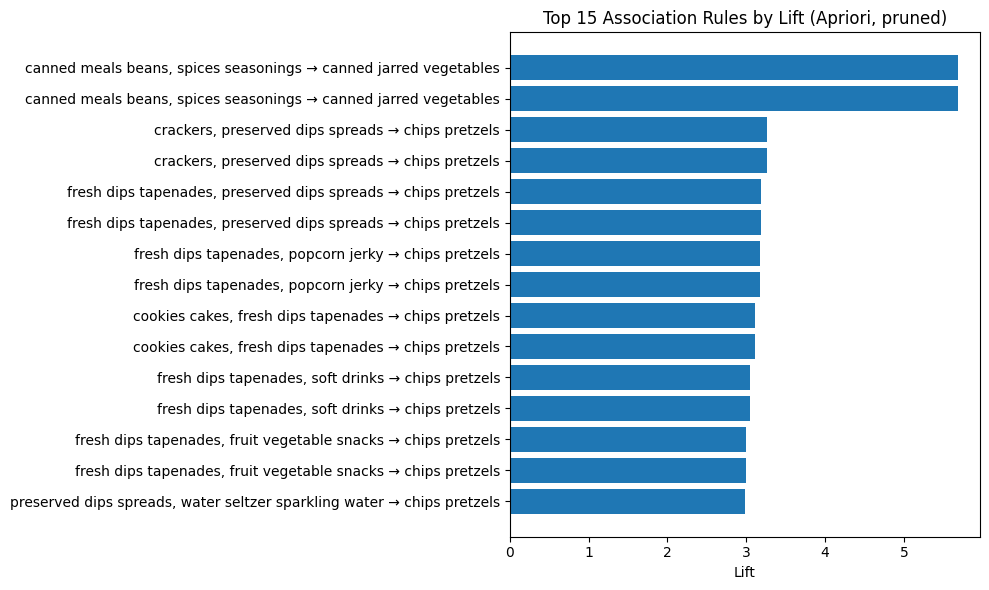

In [ ]:

top_k = 15
plot_df = (
    pruned_ap.sort_values("lift", ascending=False)
             .head(top_k)
)

plt.figure(figsize=(10, 6))
plt.barh(
    range(len(plot_df)),
    plot_df["lift"]
)
plt.yticks(
    range(len(plot_df)),
    plot_df["antecedent_str"] + " → " + plot_df["consequent_str"]
)
plt.gca().invert_yaxis()
plt.xlabel("Lift")
plt.title(f"Top {top_k} Association Rules by Lift (Apriori, pruned)")
plt.tight_layout()
plt.show()


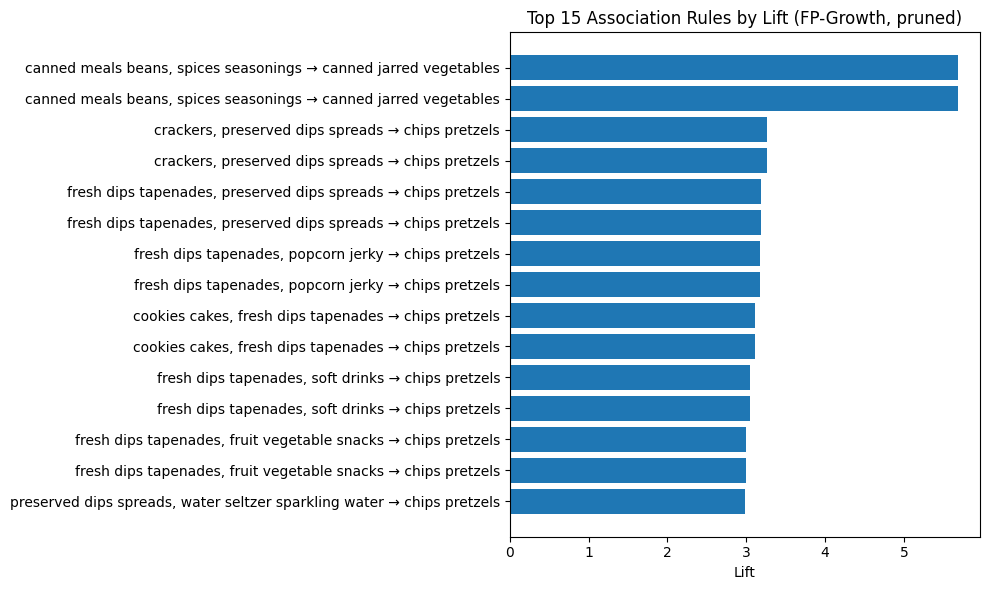

In [45]:

top_k = 15
plot_df = (
    pruned_fp.sort_values("lift", ascending=False)
             .head(top_k)
)

plt.figure(figsize=(10, 6))
plt.barh(
    range(len(plot_df)),
    plot_df["lift"]
)
plt.yticks(
    range(len(plot_df)),
    plot_df["antecedent_str"] + " → " + plot_df["consequent_str"]
)
plt.gca().invert_yaxis()
plt.xlabel("Lift")
plt.title(f"Top {top_k} Association Rules by Lift (FP-Growth, pruned)")
plt.tight_layout()
plt.show()

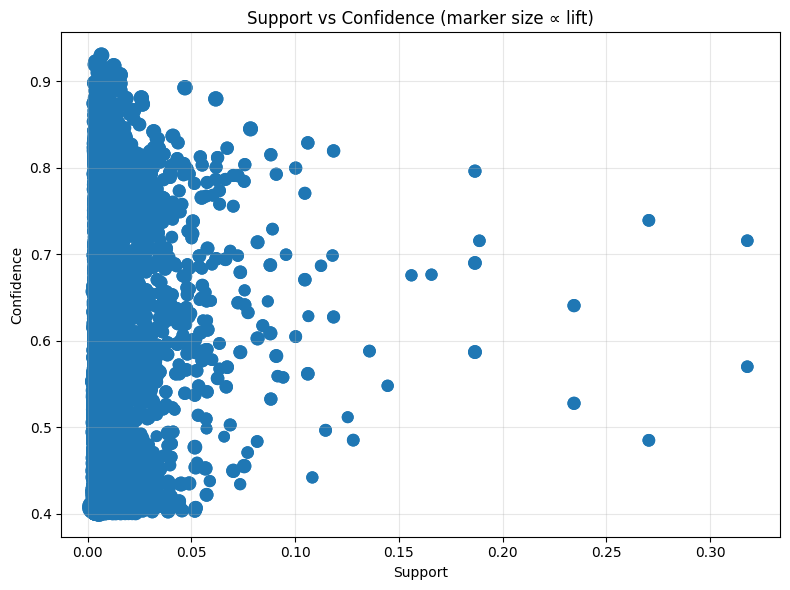

In [46]:
scatter_df = pruned_ap.copy()

plt.figure(figsize=(8, 6))
plt.scatter(
    scatter_df["support"],
    scatter_df["confidence"],
    s=50 * scatter_df["lift"]  # lift controls marker size
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (marker size ∝ lift)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

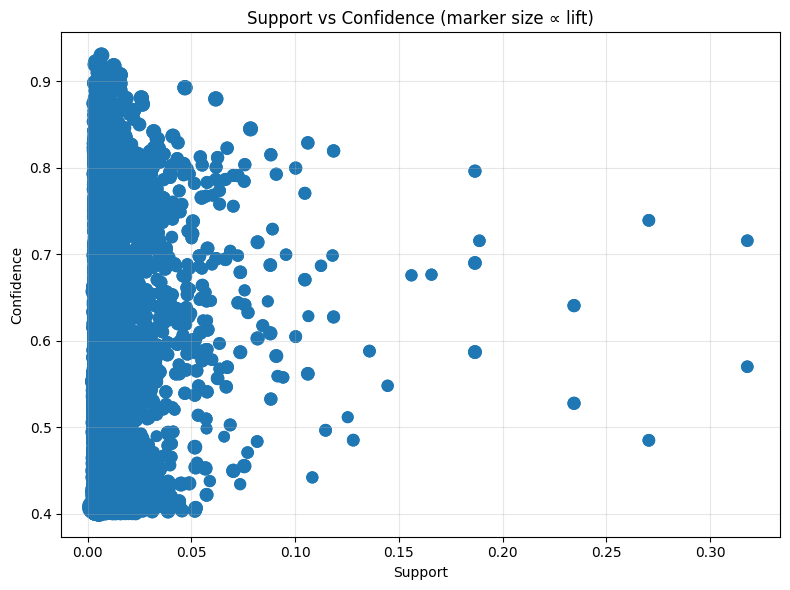

In [47]:
scatter_df = pruned_fp.copy()

plt.figure(figsize=(8, 6))
plt.scatter(
    scatter_df["support"],
    scatter_df["confidence"],
    s=50 * scatter_df["lift"]  
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (marker size ∝ lift)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Support–confidence scatter for pruned rules; marker size encodes lift, highlighting rules that are both frequent and strong.

In [48]:
final_rules = pd.concat([pruned_ap, pruned_fp], ignore_index=True)

export_cols = [
    "antecedent_str",
    "consequent_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
    "support_count",
    "antecedent_len",
    "consequent_len",
    "min_support_used",
    "algo"
]

final_rules_export = final_rules[export_cols].copy()

group_name = "KAPPA"  
filename = f"rules_{group_name}_Ecommerce.csv"
final_rules_export.to_csv(filename, index=False)

print(f"Exported {len(final_rules_export)} rules to {filename}")
final_rules_export.head()


Exported 27492 rules to rules_KAPPA_Ecommerce.csv


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction,support_count,antecedent_len,consequent_len,min_support_used,algo
0,asian foods,fresh fruits,0.027714,0.647300,1.160868,0.003840,1.254324,5203,1,1,0.003,apriori
1,asian foods,fresh vegetables,0.028220,0.659119,1.484261,0.009207,1.630857,5298,1,1,0.003,apriori
2,asian foods,packaged vegetables fruits,0.021402,0.499876,1.366707,0.005742,1.268181,4018,1,1,0.003,apriori
3,baby food formula,fresh fruits,0.034345,0.746556,1.338872,0.008693,1.745549,6448,1,1,0.003,apriori
4,baby food formula,fresh vegetables,0.025865,0.562232,1.266083,0.005436,1.269915,4856,1,1,0.003,apriori
